# L3 Regularization: Theory, Geometry & Implementation

## What is L3 Regularization?

Standard regularization uses the L1 norm (Lasso) or L2 norm (Ridge). **L3 regularization** extends this idea to the cubic penalty:

$$\min_{\beta} \; \frac{1}{2n}||y - X\beta||^2 + \alpha \sum_{j=1}^{p} |\beta_j|^3$$

### Why Study L3?
L3 is **rarely used in practice**, but it is valuable for understanding the regularization landscape:

| Property | L1 | L2 | L3 |
|----------|-----|-----|-----|
| **Convex** | Yes | Yes | Yes |
| **Differentiable** | No (at 0) | Yes | Yes |
| **Sparse** | Yes | No | No |
| **Closed-form** | No | Yes | No |
| **Aggressive large-coef shrinkage** | Moderate | Mild | Strong |

L3 sits between L2 and L-infinity: it is smooth and convex like L2, but penalizes large coefficients much more aggressively.

> **Note:** Do not confuse L3 regularization with "cubic regularization" in optimization literature (which regularizes a third-order Taylor model). Here we mean the L3 norm penalty.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Generate data with a mix of strong and weak signals
n_samples, n_features = 100, 8
X = np.random.randn(n_samples, n_features)

# True coefficients: some large, some small, some zero
true_coef = np.array([3.0, -2.5, 1.0, -0.5, 0.0, 0.0, 0.0, 0.0])
noise = np.random.randn(n_samples) * 1.5
y = X @ true_coef + noise

# Center data
X_mean = X.mean(axis=0)
y_mean = y.mean()
Xc = X - X_mean
yc = y - y_mean

# Color palette for consistent feature coloring
colors = plt.cm.tab10(np.linspace(0, 1, n_features))

print("Data shape:", X.shape)
print("True coefficients:", true_coef)
print("Non-zero features:", np.where(true_coef != 0)[0])


Data shape: (100, 8)
True coefficients: [ 3.  -2.5  1.  -0.5  0.   0.   0.   0. ]
Non-zero features: [0 1 2 3]


## 1. Mathematical Formulation

### Objective Function
$$J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^T \beta)^2 + \alpha \sum_{j=1}^{p} |\beta_j|^3$$

### Gradient
The L3 penalty is differentiable everywhere, including at zero:

$$\frac{\partial}{\partial \beta_j} |\beta_j|^3 = 3 \beta_j |\beta_j|$$

Therefore the full gradient is:

$$\nabla J(\beta) = \frac{1}{n} X^T (X\beta - y) + 3\alpha \cdot \beta \odot |\beta|$$

where $\odot$ is element-wise multiplication.

### Key Implications
- **No closed-form solution**: we must use iterative optimization (gradient descent).
- **No sparsity**: the gradient at $\beta_j = 0$ is exactly 0, so there is no "force" pushing small coefficients to exactly zero (unlike L1).
- **Super-linear shrinkage**: coefficients larger than 1 are penalized more heavily than in L2; coefficients smaller than 1 are penalized less heavily.

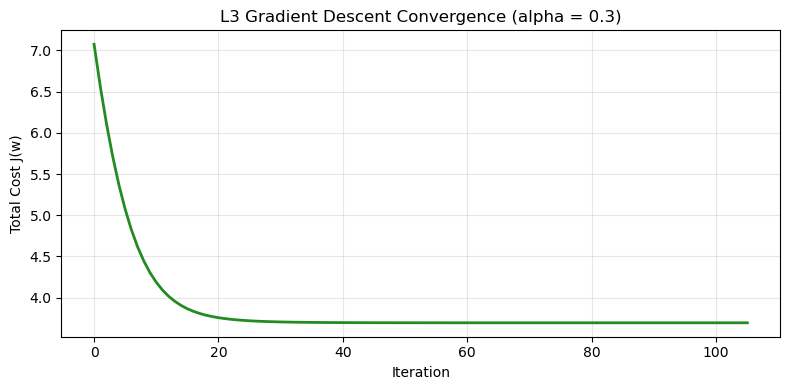

Converged in 106 iterations
Final L3 coefficients: [ 1.1538 -1.0673  0.6051 -0.5117 -0.0804  0.1681 -0.3256  0.0032]


In [2]:
def l3_gradient_descent(X, y, alpha, lr=0.05, n_iter=3000, tol=1e-7):
    """
    L3 regularized linear regression via gradient descent.
    Objective: (1/(2n)) * ||y - Xw||^2 + alpha * sum(|w_j|^3)
    """
    n, p = X.shape
    w = np.zeros(p)
    cost_history = []
    
    for i in range(n_iter):
        error = X @ w - y
        grad_mse = (1.0 / n) * X.T @ error
        grad_penalty = alpha * 3.0 * w * np.abs(w)
        grad = grad_mse + grad_penalty
        
        w = w - lr * grad
        
        mse = (1.0 / (2.0 * n)) * np.sum(error**2)
        penalty = alpha * np.sum(np.abs(w)**3)
        cost = mse + penalty
        cost_history.append(cost)
        
        if i > 0 and abs(cost_history[-2] - cost) < tol:
            break
    
    return w, np.array(cost_history)


# Demonstrate convergence
alpha_demo = 0.3
w_demo, cost_demo = l3_gradient_descent(Xc, yc, alpha_demo, lr=0.05)

plt.figure(figsize=(8, 4))
plt.plot(cost_demo, color='forestgreen', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Total Cost J(w)')
plt.title('L3 Gradient Descent Convergence (alpha = ' + str(alpha_demo) + ')')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Converged in", len(cost_demo), "iterations")
print("Final L3 coefficients:", np.round(w_demo, 4))


## 2. Geometric Intuition: Lp Constraint Regions

Regularization can be viewed as constrained optimization:

$$\min_{\beta} ||y - X\beta||^2 \quad \text{subject to} \quad \sum |\beta_j|^p \leq t$$

The shape of the feasible region determines the solution behavior:

- **L1 (p=1)**: Diamond. Corners touch axes → sparsity.
- **L2 (p=2)**: Circle. Smooth contact → no sparsity, uniform shrinkage.
- **L3 (p=3)**: Rounded "superellipse" between circle and square. Smooth contact → no sparsity, but corners are sharper than L2.
- **L-inf (p=∞)**: Square. Pushes mass to the boundary extremes.

As $p$ increases beyond 2, the unit ball becomes increasingly square-like, favoring solutions where coefficients are more evenly distributed in magnitude.


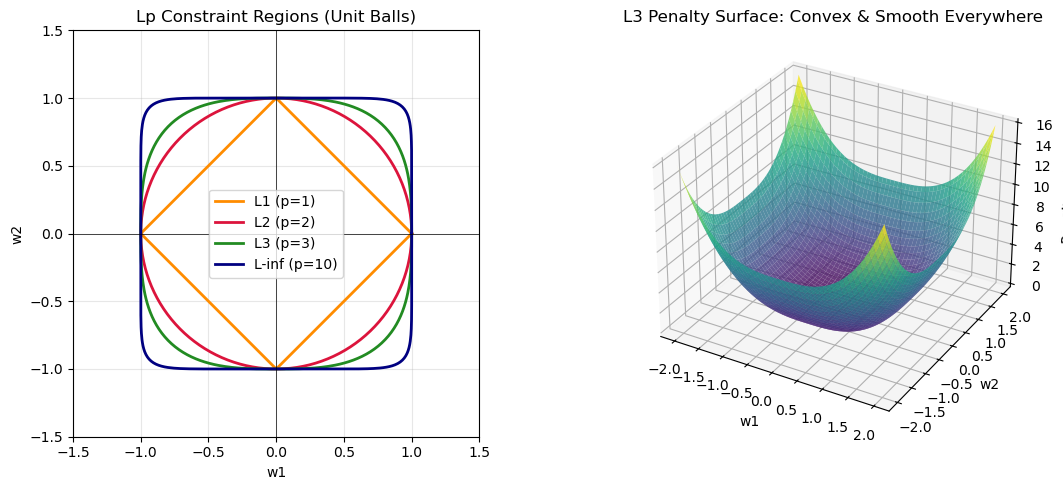

In [3]:
fig = plt.figure(figsize=(12, 5))

# --- Lp unit balls in 2D ---
ax1 = fig.add_subplot(1, 2, 1)
theta = np.linspace(0, 2 * np.pi, 400)
t = 1.0

configs = [
    (1, 'darkorange', 'L1 (p=1)'),
    (2, 'crimson', 'L2 (p=2)'),
    (3, 'forestgreen', 'L3 (p=3)'),
    (10, 'navy', 'L-inf (p=10)'),
]

for p, color, label in configs:
    # Parametric boundary of Lp unit ball: r = t / (|cos|^p + |sin|^p)^(1/p)
    denom = (np.abs(np.cos(theta))**p + np.abs(np.sin(theta))**p)**(1.0 / p)
    r = t / denom
    x_ball = r * np.cos(theta)
    y_ball = r * np.sin(theta)
    ax1.plot(x_ball, y_ball, color=color, linewidth=2, label=label)

ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)
ax1.set_aspect('equal')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_title('Lp Constraint Regions (Unit Balls)')
ax1.set_xlabel('w1')
ax1.set_ylabel('w2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- 3D surface of L3 penalty ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
w1 = np.linspace(-2, 2, 100)
w2 = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1, w2)
L3_surface = np.abs(W1)**3 + np.abs(W2)**3

ax2.plot_surface(W1, W2, L3_surface, cmap='viridis', alpha=0.8, edgecolor='none')
ax2.set_xlabel('w1')
ax2.set_ylabel('w2')
ax2.set_zlabel('Penalty value')
ax2.set_title('L3 Penalty Surface: Convex & Smooth Everywhere')

plt.tight_layout()
plt.show()


## 3. Coefficient Paths: L3 vs L2

As the regularization strength $\alpha$ increases:

- **L2 (Ridge)**: coefficients shrink smoothly toward zero, but never reach it exactly.
- **L3**: coefficients also shrink smoothly, but large coefficients are pulled down faster due to the cubic growth of the penalty.

The plots below compare the regularization paths. Notice that L3 paths drop more steeply for large initial coefficients, while L2 maintains a more gentle, linear-like decay in log-space.


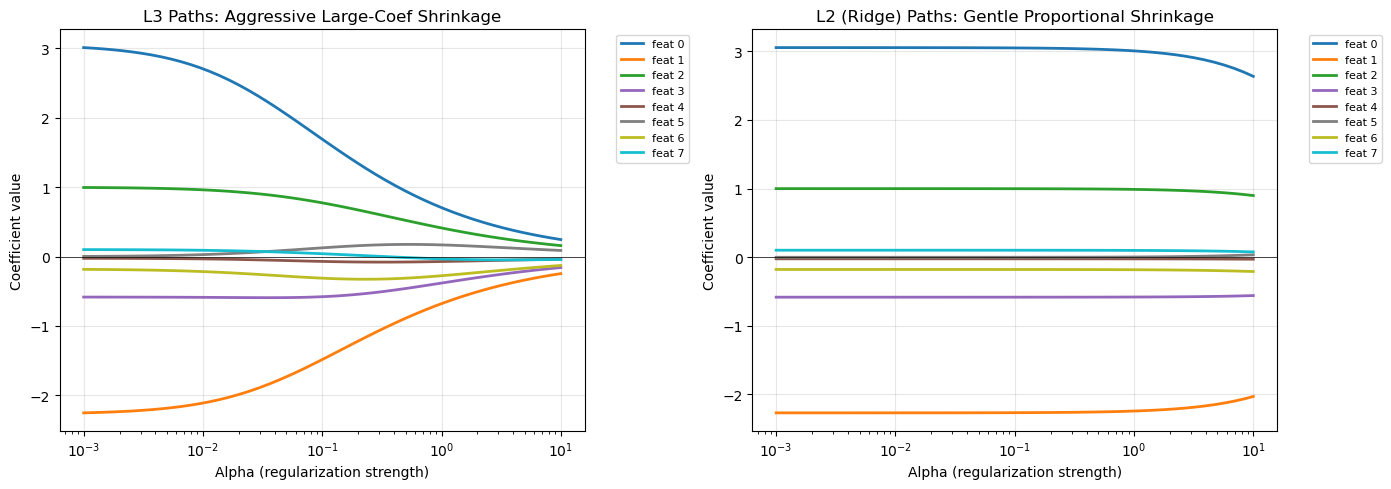

In [4]:
def ridge_closed_form(X, y, alpha):
    """Ridge regression closed-form solution."""
    n, p = X.shape
    return np.linalg.inv(X.T @ X + alpha * np.eye(p)) @ X.T @ y


alphas = np.logspace(-3, 1, 50)

l3_paths = np.zeros((len(alphas), n_features))
l2_paths = np.zeros((len(alphas), n_features))

for i, a in enumerate(alphas):
    w_l3, _ = l3_gradient_descent(Xc, yc, a, lr=0.05, n_iter=2000)
    l3_paths[i] = w_l3
    l2_paths[i] = ridge_closed_form(Xc, yc, a)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# L3 paths
ax = axes[0]
for j in range(n_features):
    ax.plot(alphas, l3_paths[:, j], color=colors[j], linewidth=2,
            label='feat ' + str(j))
ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Alpha (regularization strength)')
ax.set_ylabel('Coefficient value')
ax.set_title('L3 Paths: Aggressive Large-Coef Shrinkage')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# L2 paths
ax = axes[1]
for j in range(n_features):
    ax.plot(alphas, l2_paths[:, j], color=colors[j], linewidth=2,
            label='feat ' + str(j))
ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Alpha (regularization strength)')
ax.set_ylabel('Coefficient value')
ax.set_title('L2 (Ridge) Paths: Gentle Proportional Shrinkage')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Why L3 Cannot Induce Sparsity

The key to understanding sparsity lies in the **derivative of the penalty at zero**:

| Penalty | Formula | Derivative at 0 | Effect |
|---------|---------|-----------------|--------|
| **L1** | $\|\beta\|$ | Subgradient $[-1, 1]$ | Can "pull" coefficient to exactly 0 |
| **L2** | $\beta^2$ | 0 | No pull; coefficient stays wherever the loss gradient balances |
| **L3** | $\|\beta\|^3$ | 0 | No pull; smooth minimum at origin but no thresholding |

Because the L3 derivative at zero is exactly zero, a coefficient that starts at zero (or becomes very small) experiences **no regularization force** to move it away from zero, but also **no force** to push it exactly to zero. The gradient descent update depends entirely on the MSE gradient.

Contrast this with L1: even when the MSE gradient is small, the L1 subgradient can dominate and snap the coefficient to zero (hard thresholding).

The plots below visualize the penalty shapes and their derivatives.


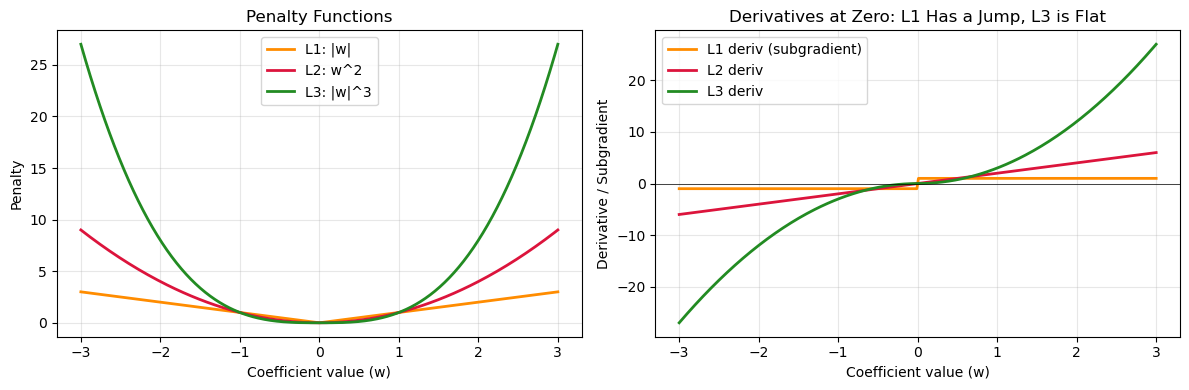

In [5]:
w_range = np.linspace(-3, 3, 300)

# Penalty functions
l1_pen = np.abs(w_range)
l2_pen = w_range**2
l3_pen = np.abs(w_range)**3

# Derivatives
l1_deriv = np.sign(w_range)
l1_deriv[np.isclose(w_range, 0, atol=1e-3)] = np.nan  # show discontinuity
l2_deriv = 2 * w_range
l3_deriv = 3 * w_range * np.abs(w_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(w_range, l1_pen, color='darkorange', linewidth=2, label='L1: |w|')
ax.plot(w_range, l2_pen, color='crimson', linewidth=2, label='L2: w^2')
ax.plot(w_range, l3_pen, color='forestgreen', linewidth=2, label='L3: |w|^3')
ax.set_xlabel('Coefficient value (w)')
ax.set_ylabel('Penalty')
ax.set_title('Penalty Functions')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(w_range, l1_deriv, color='darkorange', linewidth=2, label='L1 deriv (subgradient)')
ax.plot(w_range, l2_deriv, color='crimson', linewidth=2, label='L2 deriv')
ax.plot(w_range, l3_deriv, color='forestgreen', linewidth=2, label='L3 deriv')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient value (w)')
ax.set_ylabel('Derivative / Subgradient')
ax.set_title('Derivatives at Zero: L1 Has a Jump, L3 is Flat')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Practical Comparison

### When Would You Use L3?
**Short answer: almost never.** The machine learning standard toolkit is L1, L2, and Elastic Net. However, L3 is theoretically interesting because:

1. **Heavy-tailed coefficient priors**: If you believe the true model has a few very large coefficients that need strong suppression, L3 penalizes them more aggressively than L2.
2. **Smooth optimization**: Unlike L1, L3 is everywhere differentiable, so standard gradient descent converges smoothly without subgradient tricks.
3. **Bridge between L2 and L-inf**: As $p \to \infty$, Lp regularization pushes coefficients toward equal magnitude (max-norm). L3 is a step in that direction.

### Computational Note
L3 has no closed-form solution and no efficient proximal operator. Each fit requires iterative optimization, making it slower than Ridge and less interpretable than Lasso.

### Summary
| Criterion | OLS | L1 (Lasso) | L2 (Ridge) | L3 |
|-----------|-----|------------|------------|-----|
| **Sparsity** | No | Yes | No | No |
| **Closed form** | Yes | No | Yes | No |
| **Differentiable** | Yes | No | Yes | Yes |
| **Large-coef suppression** | None | Moderate | Mild | Strong |
| **Typical use** | Baseline | Feature selection | Multicollinearity | Theoretical only |


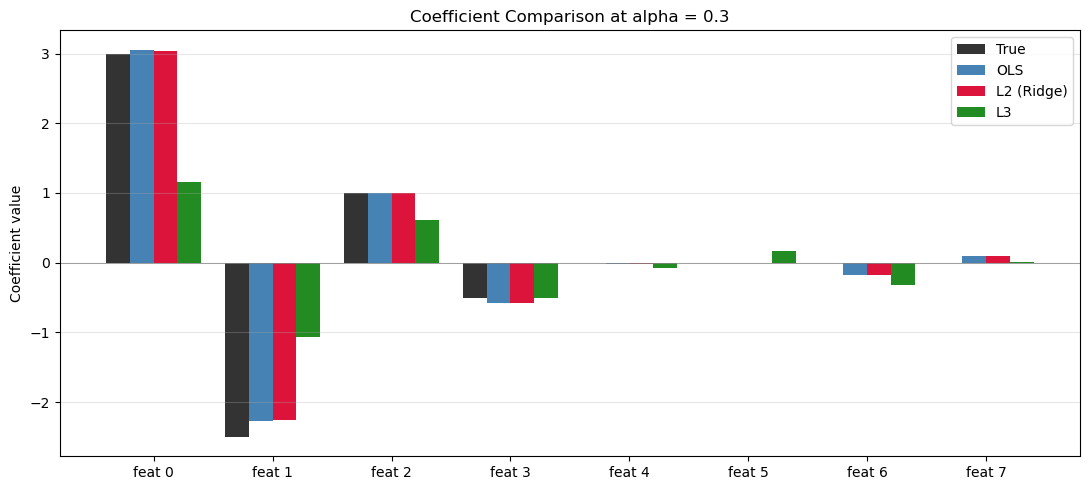

=== Quantitative Comparison at alpha = 0.3 ===
Method   |  L0 (non-zero)  |  L1 norm  |  L2 norm  |  L3 norm
-----------------------------------------------------------------
OLS      |               8  |     7.217  |     3.984  |     3.461
L2       |               8  |     7.190  |     3.968  |     3.445
L3       |               8  |     3.915  |     1.800  |     1.465


In [6]:
alpha_comp = 0.3

w_ols = np.linalg.lstsq(Xc, yc, rcond=None)[0]
w_l2 = ridge_closed_form(Xc, yc, alpha_comp)
w_l3, _ = l3_gradient_descent(Xc, yc, alpha_comp, lr=0.05)

x_pos = np.arange(n_features)
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_pos - 1.5*width, true_coef, width, label='True', color='black', alpha=0.8)
ax.bar(x_pos - 0.5*width, w_ols, width, label='OLS', color='steelblue')
ax.bar(x_pos + 0.5*width, w_l2, width, label='L2 (Ridge)', color='crimson')
ax.bar(x_pos + 1.5*width, w_l3, width, label='L3', color='forestgreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(['feat ' + str(i) for i in range(n_features)])
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Coefficient value')
ax.set_title('Coefficient Comparison at alpha = ' + str(alpha_comp))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Quantitative comparison
print("=== Quantitative Comparison at alpha =", alpha_comp, "===")
print("Method   |  L0 (non-zero)  |  L1 norm  |  L2 norm  |  L3 norm")
print("-" * 65)
for name, w in [('OLS', w_ols), ('L2', w_l2), ('L3', w_l3)]:
    l0 = np.sum(np.abs(w) > 1e-4)
    l1 = np.sum(np.abs(w))
    l2 = np.sqrt(np.sum(w**2))
    l3 = np.sum(np.abs(w)**3)**(1.0/3.0)
    print("{0:8s} |  {1:14d}  |  {2:8.3f}  |  {3:8.3f}  |  {4:8.3f}".format(name, int(l0), l1, l2, l3))
